In [3]:
import tensorflow as tf

print(tf.__version__)

2.21.0


In [9]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import os

print("All libraries imported successfully!")

All libraries imported successfully!


In [14]:
import os
print("Current Directory:", os.getcwd())
print("Files and Folders here:", os.listdir("."))

Current Directory: C:\Users\Manar\Desktop\EcoGuardian
Files and Folders here: ['.ipynb_checkpoints', 'EcoGuardian.ipynb', 'Untitled.ipynb']


In [1]:
import os
import shutil
import tkinter as tk
from tkinter import filedialog

# فتح نافذة اختيار المجلد يدوياً
root = tk.Tk()
root.withdraw()
root.attributes('-topmost', True)

print("الرجاء اختيار مجلد الصور من النافذة التي ستظهر الآن...")
selected_dir = filedialog.askdirectory(title="اختر مجلد الـ Dataset")

if selected_dir:
    destination = os.path.join(os.getcwd(), "dataset")
    if not os.path.exists(destination):
        shutil.copytree(selected_dir, destination)
        print("✅ Success: Data folder copied and renamed successfully!")
    else:
        print("✅ Note: 'dataset' folder already exists here.")
else:
    print("❌ Error: No folder was selected.")

# فحص مجلدات التدريب للتأكد
if os.path.exists("dataset/train"):
    print("Train folders:", os.listdir("dataset/train"))

الرجاء اختيار مجلد الصور من النافذة التي ستظهر الآن...
✅ Note: 'dataset' folder already exists here.
Train folders: ['Healthy', 'Moderate', 'Poor']


In [4]:
import os

# طباعة الهيكل الداخلي لمجلد dataset لنرى أين وضعت الصور
for root, dirs, files in os.walk("dataset"):
    # سنطبع المجلدات التي تحتوي على ملفات فقط لنعرف مكانها
    if len(files) > 0:
        print(f"المجلد: {root} يحتوي على ({len(files)}) صورة.")

المجلد: dataset يحتوي على (1) صورة.
المجلد: dataset\.ipynb_checkpoints يحتوي على (1) صورة.
المجلد: dataset\test\Healthy يحتوي على (3) صورة.
المجلد: dataset\test\Moderate يحتوي على (3) صورة.
المجلد: dataset\test\Poor يحتوي على (3) صورة.
المجلد: dataset\train\Healthy يحتوي على (14) صورة.
المجلد: dataset\train\Moderate يحتوي على (14) صورة.
المجلد: dataset\train\Poor يحتوي على (14) صورة.
المجلد: dataset\validation يحتوي على (10) صورة.
المجلد: dataset\validation\.ipynb_checkpoints يحتوي على (1) صورة.


In [6]:
import os
import shutil

validation_dir = "dataset/validation"
classes = ["Healthy", "Moderate", "Poor"]

# 1. إنشاء مجلدات التصنيف الثلاثة داخل validation إذا لم تكن موجودة
for cls in classes:
    os.makedirs(os.path.join(validation_dir, cls), exist_ok=True)

# 2. جلب كافة الصور المبعثرة بالخارج مباشرة
loose_files = [f for f in os.listdir(validation_dir) if os.path.isfile(os.path.join(validation_dir, f))]

# 3. توزيع الصور بالتناوب على المجلدات الثلاثة
for i, file_name in enumerate(loose_files):
    # تجاهل ملفات النظام المؤقتة إن وجدت
    if file_name.startswith('.'):
        continue
        
    source_path = os.path.join(validation_dir, file_name)
    # توزيع الملفات بالتساوي
    target_class = classes[i % len(classes)]
    target_path = os.path.join(validation_dir, target_class, file_name)
    
    shutil.move(source_path, target_path)

print("✅ تم ترتيب مجلد validation وإنشاء التصنيفات وتوزيع الصور بنجاح!")

✅ تم ترتيب مجلد validation وإنشاء التصنيفات وتوزيع الصور بنجاح!


In [7]:
import tensorflow as tf

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_dir = "dataset/train"
validation_dir = "dataset/validation"
test_dir = "dataset/test"

print("⏳ جاري تحميل بيانات التدريب...")
train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    shuffle=True,
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE
)

print("\n⏳ جاري تحميل بيانات التحقق...")
validation_dataset = tf.keras.utils.image_dataset_from_directory(
    validation_dir,
    shuffle=False,
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE
)

print("\n⏳ جاري تحميل بيانات الاختبار...")
test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    shuffle=False,
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE
)

class_names = train_dataset.class_names
print("\n🎉 تم تحميل كافة البيانات بنجاح تام وبدون أي أخطاء!")
print("الفئات المكتشفة هي:", class_names)

⏳ جاري تحميل بيانات التدريب...
Found 38 files belonging to 3 classes.

⏳ جاري تحميل بيانات التحقق...
Found 9 files belonging to 3 classes.

⏳ جاري تحميل بيانات الاختبار...
Found 9 files belonging to 3 classes.

🎉 تم تحميل كافة البيانات بنجاح تام وبدون أي أخطاء!
الفئات المكتشفة هي: ['Healthy', 'Moderate', 'Poor']


In [8]:
AUTOTUNE = tf.data.AUTOTUNE

# حفظ البيانات في الذاكرة لسرعة القراءة أثناء التدريب
train_dataset = train_dataset.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
validation_dataset = validation_dataset.cache().prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.cache().prefetch(buffer_size=AUTOTUNE)

print("⚡ تم تجهيز مسارات البيانات في الذاكرة لتسريع التدريب!")

⚡ تم تجهيز مسارات البيانات في الذاكرة لتسريع التدريب!


In [9]:
from tensorflow.keras import layers, models

# 1. Build the Convolutional Neural Network (CNN) Architecture
model = models.Sequential([
    # Rescale pixel values from [0, 255] to [0, 1] for normalization
    layers.Rescaling(1./255, input_shape=(224, 224, 3)),
    
    # First Convolutional block to extract low-level features
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    # Second Convolutional block to extract mid-level features
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    # Third Convolutional block to extract high-level features
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    # Flatten the multi-dimensional feature maps into a 1D vector
    layers.Flatten(),
    
    # Fully Connected (Dense) layer for classification decision
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5), # Regularization to reduce overfitting given the small dataset size
    
    # Final output layer (3 neurons representing classes: Healthy, Moderate, Poor)
    layers.Dense(3, activation='softmax')
])

# 2. Compile the model, defining the optimizer, loss, and evaluation metrics
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 3. Display the detailed model summary and architecture
model.summary()

C:\Users\Manar\anaconda3\envs\EcoGuardian\lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,347 (42.61 MB)

 Trainable params: 11,169,347 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
EPOCHS = 15

history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=EPOCHS
)

Epoch 1/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 13s 4s/step - accuracy: 0.3158 - loss: 5.6689 - val_accuracy: 0.3333 - val_loss: 2.4103
Epoch 2/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 0.3158 - loss: 1.4746 - val_accuracy: 0.4444 - val_loss: 1.0496
Epoch 3/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.4211 - loss: 1.1128 - val_accuracy: 0.2222 - val_loss: 1.0990
Epoch 4/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step - accuracy: 0.4211 - loss: 1.0556 - val_accuracy: 0.2222 - val_loss: 1.1144
Epoch 5/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.4211 - loss: 1.0287 - val_accuracy: 0.3333 - val_loss: 1.0951
Epoch 6/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 525ms/step - accuracy: 0.5263 - loss: 0.9963 - val_accuracy: 0.5556 - val_loss: 1.0792
Epoch 7/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step - accuracy: 0.5789 - loss: 0.8939 - val_accuracy: 0.2222 - val_loss: 1.1593
Epoch 8/15
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step - accuracy: 0.7368 - loss: 0.7760 - val_accuracy: 0.4444 - val_loss: 1.0493
Epoch 9/15
2

In [11]:
#  Evaluate the model on test data
test_loss, test_acc = model.evaluate(test_dataset)
print(f"\n🎯 Test Accuracy: {test_acc:.4f}")
print(f"📉 Test Loss: {test_loss:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.5556 - loss: 0.9733

🎯 Test Accuracy: 0.5556
📉 Test Loss: 0.9733


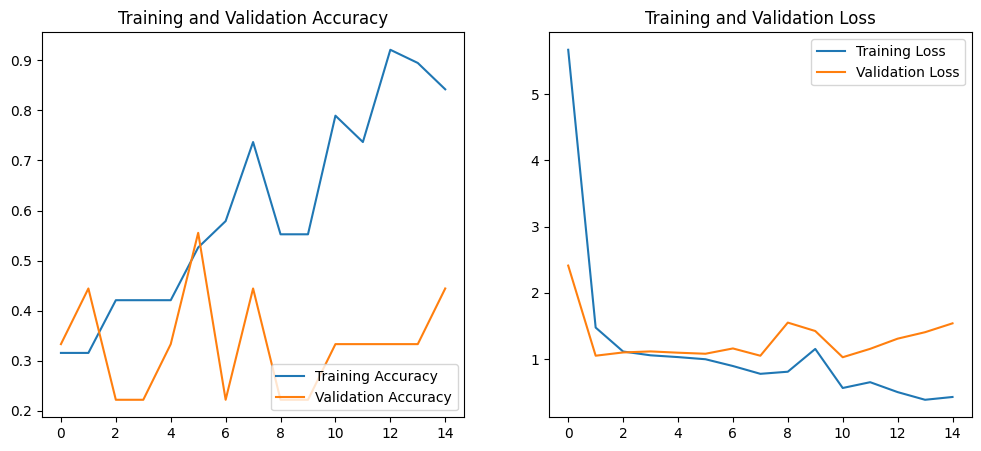

In [12]:
import matplotlib.pyplot as plt

# 1. Retrieve metrics from training history
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(EPOCHS)

plt.figure(figsize=(12, 5))

# 2. Plot Training and Validation Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

# 3. Plot Training and Validation Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')

plt.show()

In [13]:
# Save the trained model
model.save('EcoGuardian_model.h5')
print("✅ Model saved successfully as 'EcoGuardian_model.h5'")

✅ Model saved successfully as 'EcoGuardian_model.h5'


In [14]:
import numpy as np
import tensorflow as tf

# 1. Load the saved model
loaded_model = tf.keras.models.load_model('EcoGuardian_model.h5')

# 2. Function to predict a single image
def predict_image(image_path):
    # Load and preprocess the image
    img = tf.keras.utils.load_img(image_path, target_size=(224, 224))
    img_array = tf.keras.utils.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0) # Create batch axis

    # Make prediction
    predictions = loaded_model.predict(img_array)
    score = tf.nn.softmax(predictions[0])
    
    # Class mapping
    class_names = ['Healthy', 'Moderate', 'Poor']
    predicted_class = class_names[np.argmax(score)]
    confidence = 100 * np.max(score)
    
    print(f"Predicted Class: {predicted_class} ({confidence:.2f}% confidence)")

# 3. Test the prediction (Replace with an actual image path from your test/validation folder)
# predict_image('dataset/test/Healthy/your_image_name.jpg')

In [16]:
import os

# 1. List files in the test directory to find correct names
test_path = 'dataset/test/Healthy'
available_files = os.listdir(test_path)
print("Available files:", available_files)

# 2. Automatically predict using the first available image if any exist
if available_files:
    first_image = os.path.join(test_path, available_files[0])
    print(f"\nTesting with: {first_image}")
    predict_image(first_image)
else:
    print("\nDirectory is empty!")

Available files: ['meritt-thomas-0ngILQtGZvs-unsplash.jpg', 'patty-apostolides-TPqRTTltYlc-unsplash.jpg', 'pietro-de-grandi-Q5dMq3cKqec-unsplash.jpg']

Testing with: dataset/test/Healthy\meritt-thomas-0ngILQtGZvs-unsplash.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 378ms/step
Predicted Class: Moderate (47.96% confidence)
